## setup

In [11]:
import pandas as pd 
import textdescriptives as td
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

df_full = pd.read_parquet('../data/TEXT/processed/full_story_surface_metrics.parquet')
# df_inter = pd.read_parquet('../data/TEXT/processed/interaction_level_surface_metrics.parquet')


In [12]:
df_full

,text,first_order_coherence,second_order_coherence,passed_quality_check,n_stop_words,alpha_ratio,mean_word_length,doc_length,symbol_to_word_ratio_#,proportion_ellipsis,...,flesch_reading_ease,flesch_kincaid_grade,smog,gunning_fog,automated_readability_index,coleman_liau_index,lix,rix,type,conversation_id
0,This is the story of\n\nThere once was a young...,0.884638,0.880314,True,134.0,0.896000,4.120000,250.0,0.0,0.0,...,89.617419,3.288945,7.168622,6.037013,4.624614,7.464107,28.038961,1.818182,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
1,". She looked at the dark sea, waiting for sign...",0.801693,0.817447,True,160.0,0.871287,3.689769,303.0,0.0,0.0,...,99.503168,1.625051,5.250761,4.224480,2.394646,5.027176,21.248223,1.103448,user,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a
2,"This is the story of\n\nJohn Cena, the famous ...",0.862933,0.873148,True,134.0,0.806452,3.316129,310.0,0.0,0.0,...,98.465195,2.851584,5.822114,6.019456,3.635399,4.923651,24.177271,1.444444,user,conv_0bb56093-3033-4615-bb70-ebfa4135589a
3,This is the story of\n\na small town girl who ...,0.810470,0.823132,True,124.0,0.893617,4.351064,282.0,0.0,0.0,...,71.803529,7.467451,10.203070,10.407843,9.234706,10.129412,39.745098,3.866667,user,conv_0f18b30f-7d4b-4681-b98e-a0ff4f2b5256
4,"This is the story of\n\nA young girl, riding h...",0.779335,0.779396,True,148.0,0.796970,3.557576,330.0,0.0,0.0,...,95.917802,2.291391,6.238725,5.102856,3.268569,5.926412,26.115917,1.592593,user,conv_11293fd2-d757-471f-8e2e-783542167a8e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,depth and layers I hadn't considered before. T...,0.847630,0.842253,True,183.0,0.862360,4.008427,356.0,0.0,0.0,...,74.727707,5.807510,9.387100,8.797378,5.878896,8.352241,33.030234,2.520000,ai,conv_da1c7ee9-2479-4f47-94bc-db9161a6e88c
77,"to the diamond mine, their joyful voices echoi...",0.927630,0.929432,True,150.0,0.857558,4.081395,344.0,0.0,0.0,...,69.396524,10.858843,9.642633,13.494744,14.937440,10.301980,52.166894,6.700000,ai,conv_e335739c-0072-4945-8fe4-457a04c0997b
78,This is the story of a lighthouse keeper who s...,0.781368,0.789013,True,131.0,0.789137,3.875399,313.0,0.0,0.0,...,91.794801,2.373349,6.322622,4.706933,4.225043,7.575061,27.556807,1.531250,ai,conv_e73d720a-ff86-4c9b-b988-d6cc879215d9
79,"This is the story of a young girl named Ava, w...",0.884299,0.883859,True,165.0,0.863768,3.776812,345.0,0.0,0.0,...,78.972902,8.309974,8.076483,10.995336,10.775739,7.952628,40.116325,3.833333,ai,conv_f5028a6e-05a3-4757-84d0-491a6f400c24


### Plotting AI vs User surface metrics (Full story)

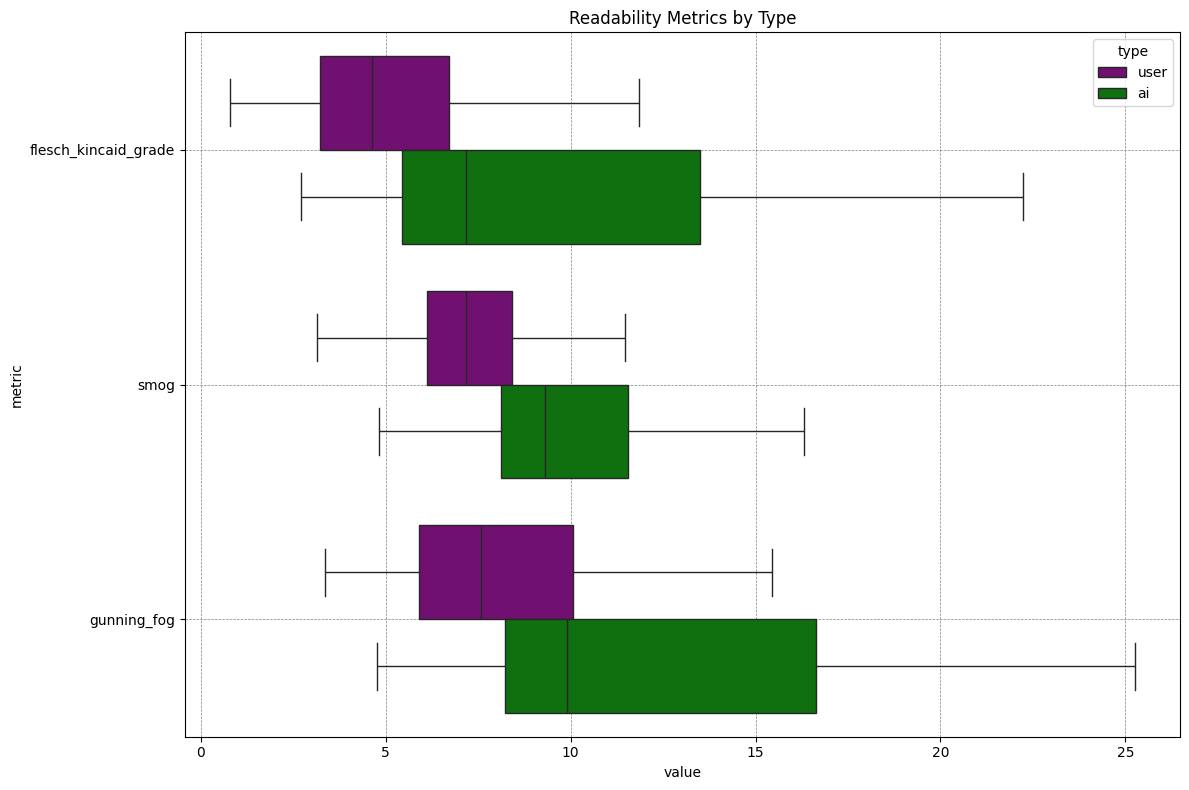

In [46]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog']

df_long = df_full.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers = False
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecate

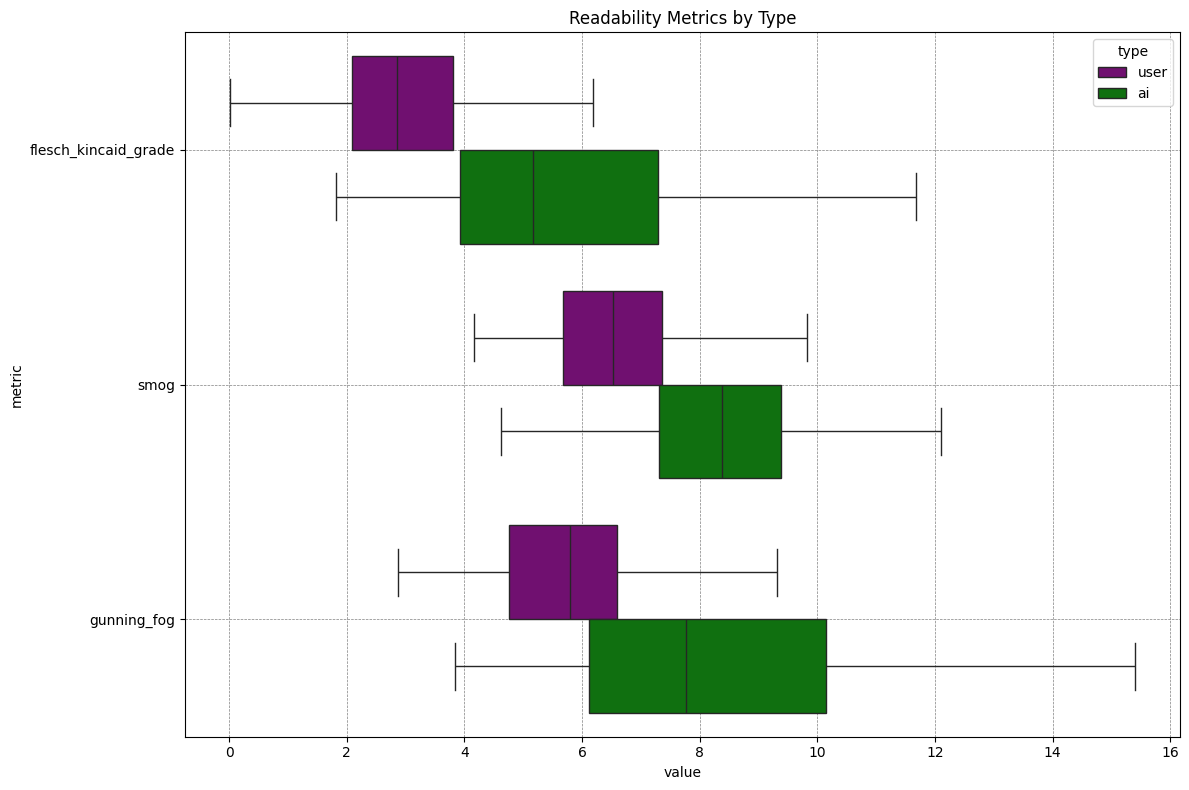

In [13]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog']

df_long = df_full.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers = False
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecate

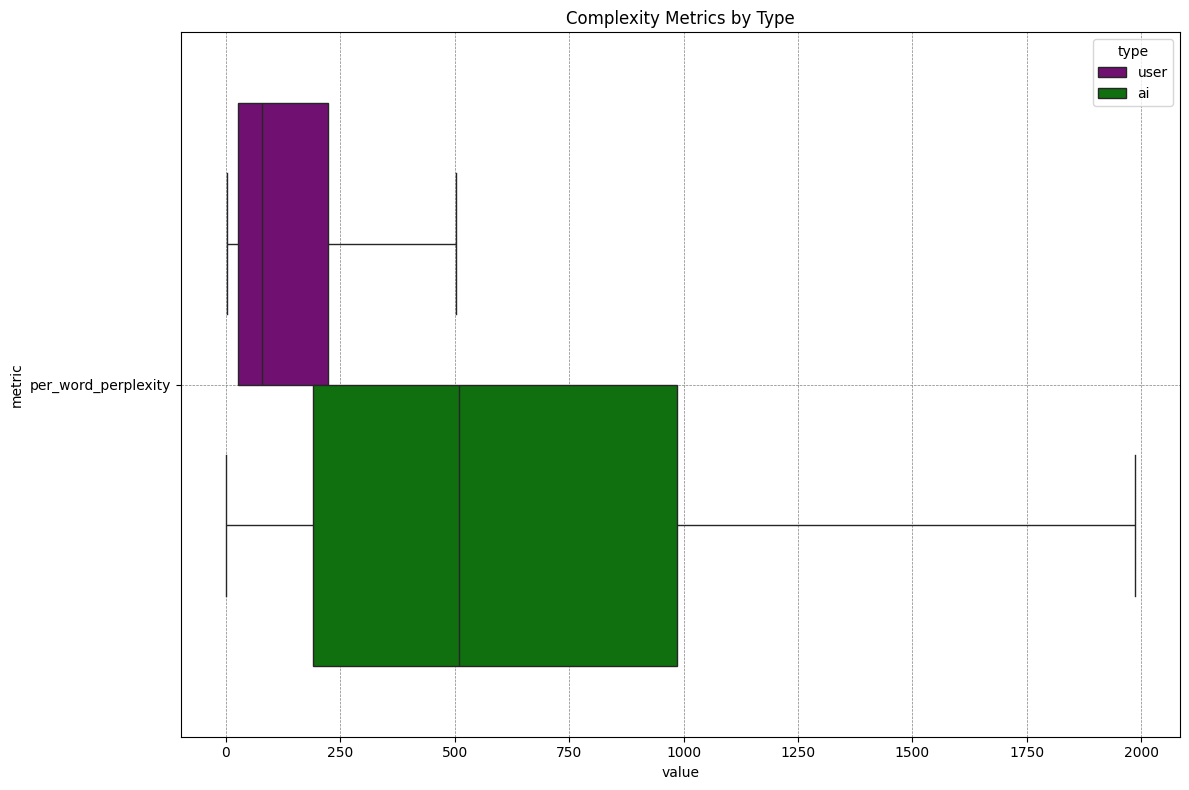

In [14]:
# complexity = ['entropy', 'perplexity']
complexity = ['per_word_perplexity']
df_long = df_full.melt(id_vars='type', value_vars=complexity, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers=False
)


plt.title('Complexity Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecate

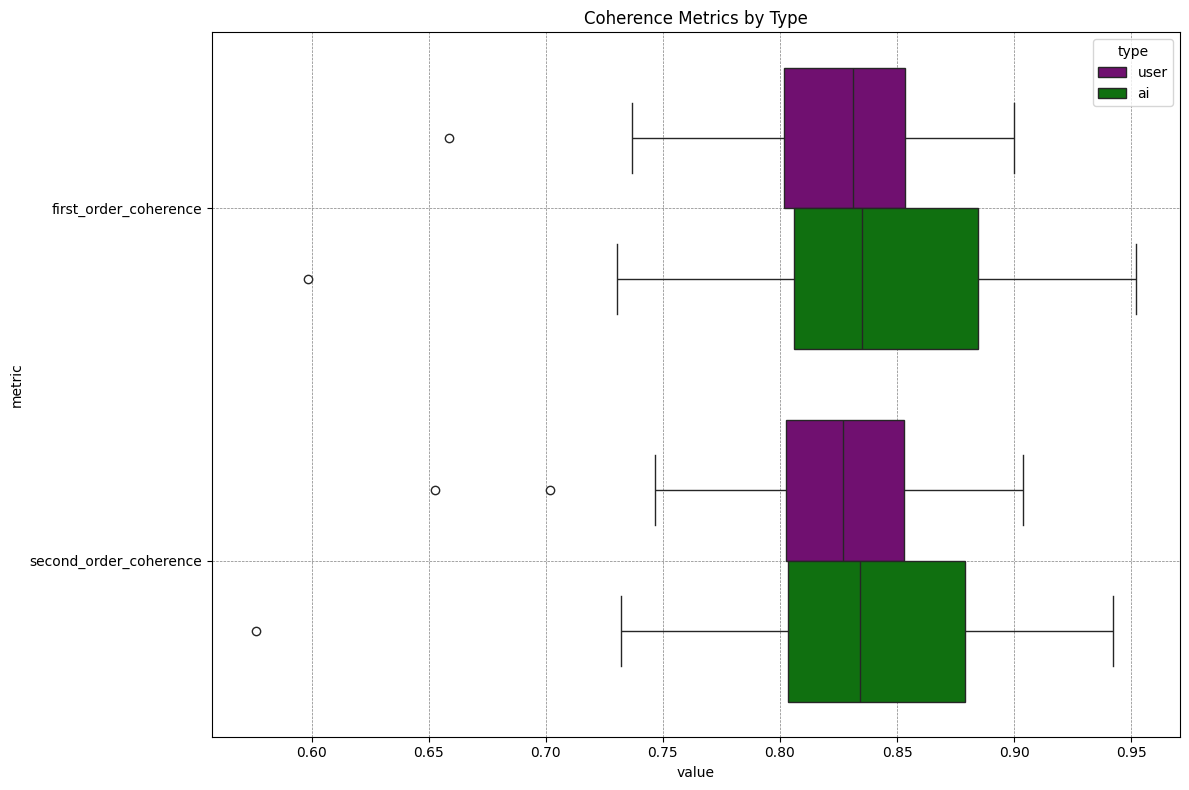

In [17]:
coherence = ['first_order_coherence', 'second_order_coherence']
df_long = df_full.melt(id_vars='type', value_vars=coherence, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Coherence Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecate

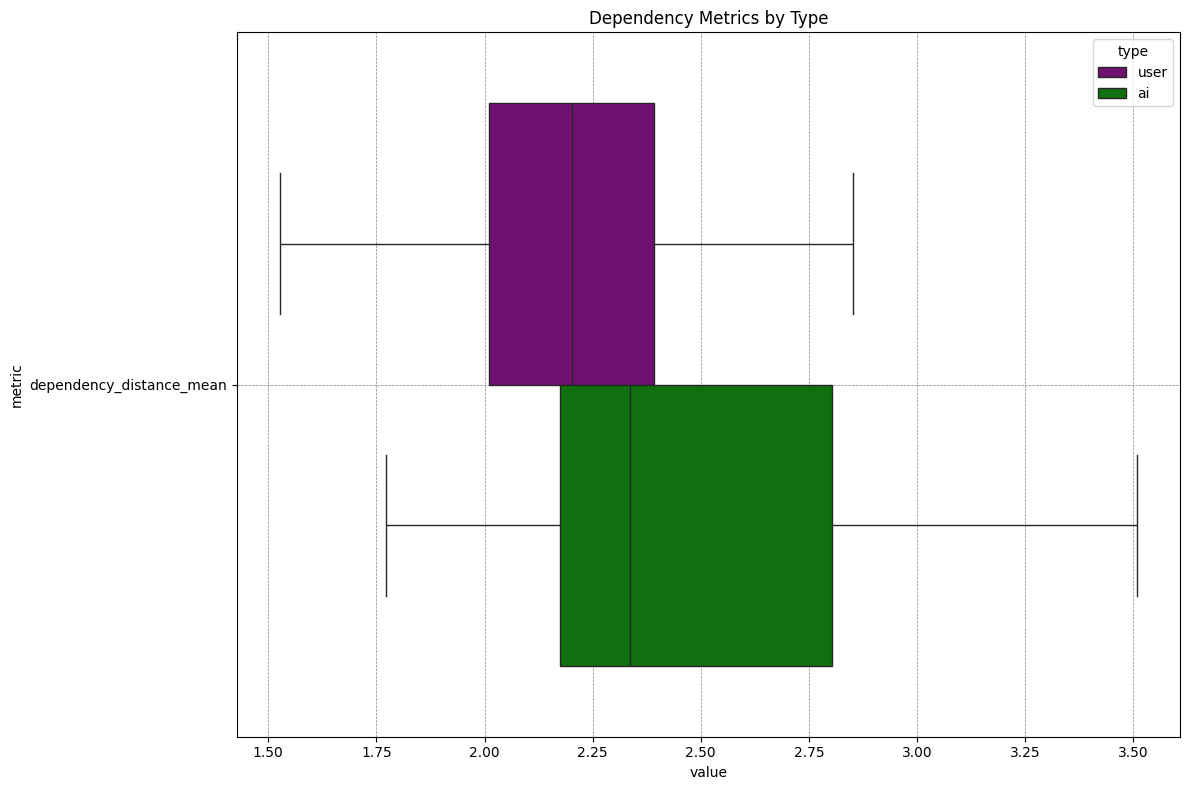

In [18]:
dependency = ['dependency_distance_mean']
df_long = df_full.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers=False
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ucloud/.local/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecate

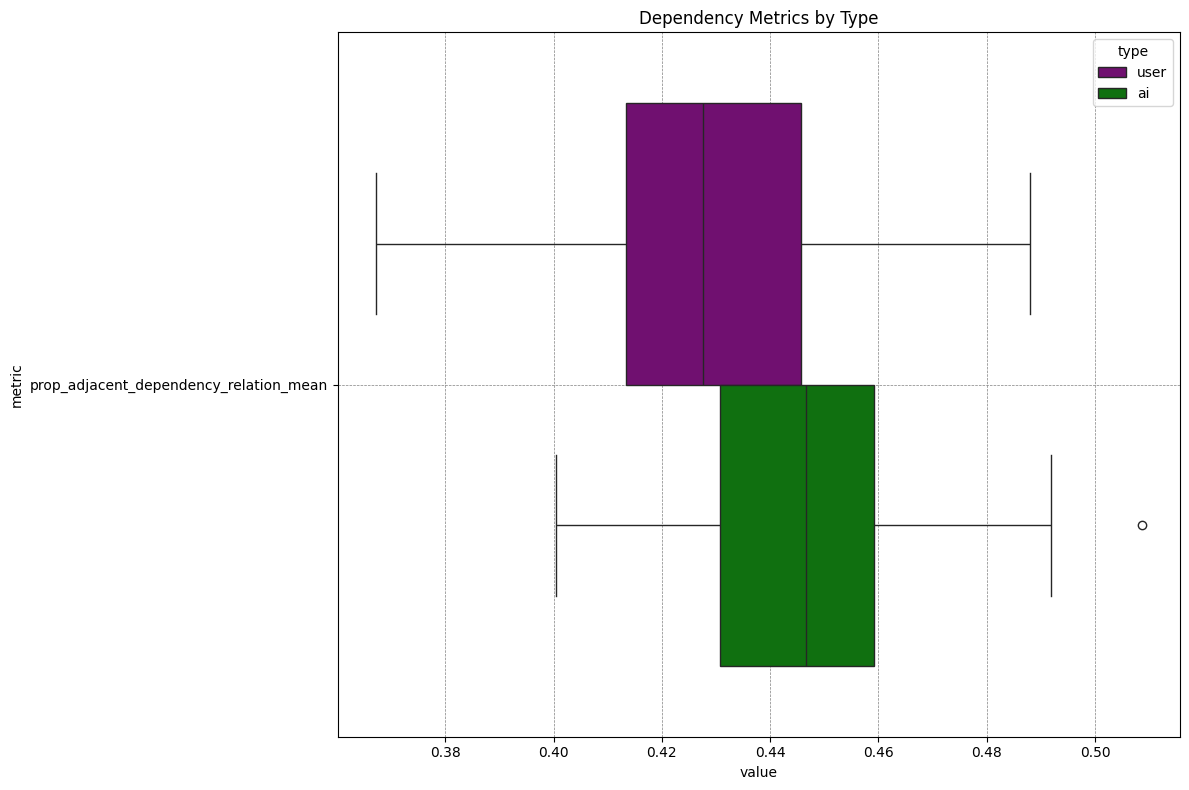

In [19]:
dependency = ['prop_adjacent_dependency_relation_mean']
df_long = df_full.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

In [21]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

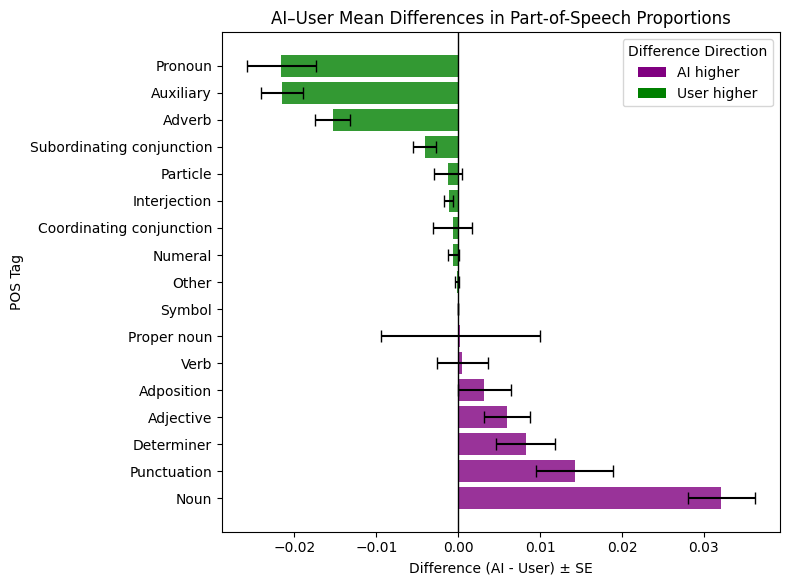

In [22]:
metrics = [col for col in df_full.columns if col.startswith('pos_')]

# Compute group stats
group_means = df_full.groupby('type')[metrics].mean().T
group_sds = df_full.groupby('type')[metrics].std().T
group_ns = df_full['type'].value_counts()

# Standard error of the difference: sqrt(s1²/n1 + s2²/n2)
se_diff = np.sqrt(
    (group_sds['ai']**2 / group_ns['ai']) +
    (group_sds['user']**2 / group_ns['user'])
)

# Difference in means
group_means['diff'] = group_means['ai'] - group_means['user']
group_means['se_diff'] = se_diff

# Sort for display
subset = group_means.sort_values('diff', ascending=False)
subset = subset.rename(index = lambda col: pos_names.get(col.split('_')[-1], col).capitalize())

# --- Plot ---
plt.figure(figsize=(8, max(4, len(subset)*0.35)))
colors = subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')


plt.barh(
    subset.index,
    subset['diff'],
    xerr=subset['se_diff'],
    color=colors,
    # ecolor=colors,          # match bar color
    capsize=4,
    alpha=0.8
)

plt.axvline(0, color='black', linewidth=1)
plt.title("AI–User Mean Differences in Part-of-Speech Proportions")
plt.xlabel("Difference (AI - User) ± SE")
plt.ylabel("POS Tag")

legend_elements = [
    Patch(facecolor='purple', label='AI higher'),
    Patch(facecolor='green', label='User higher')
]

plt.legend(handles=legend_elements, title="Difference Direction")

plt.tight_layout()
plt.show()


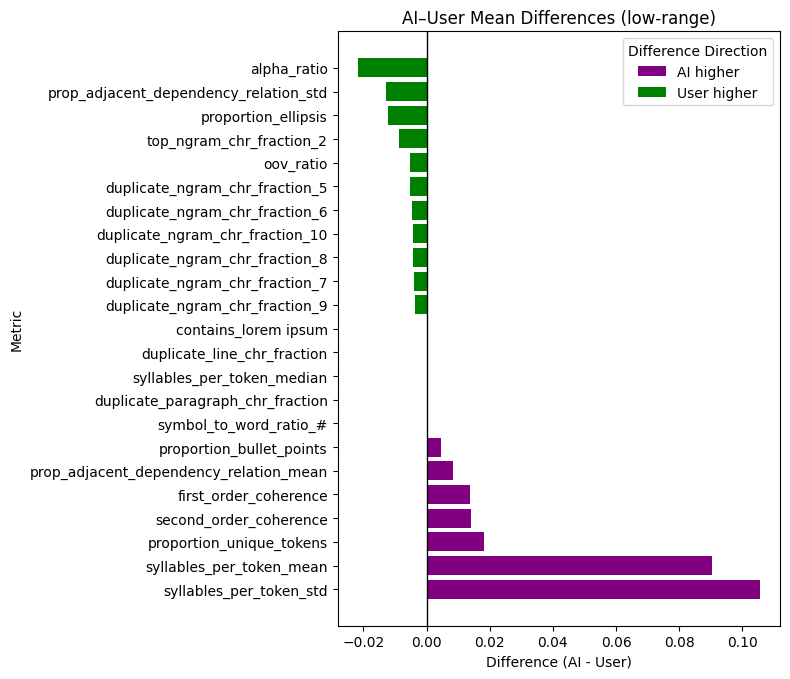

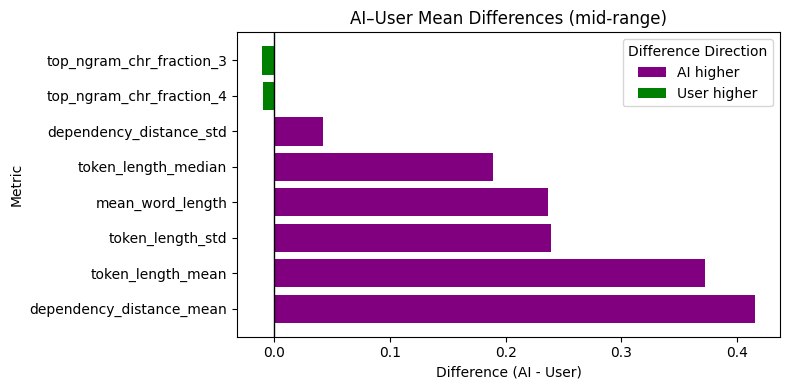

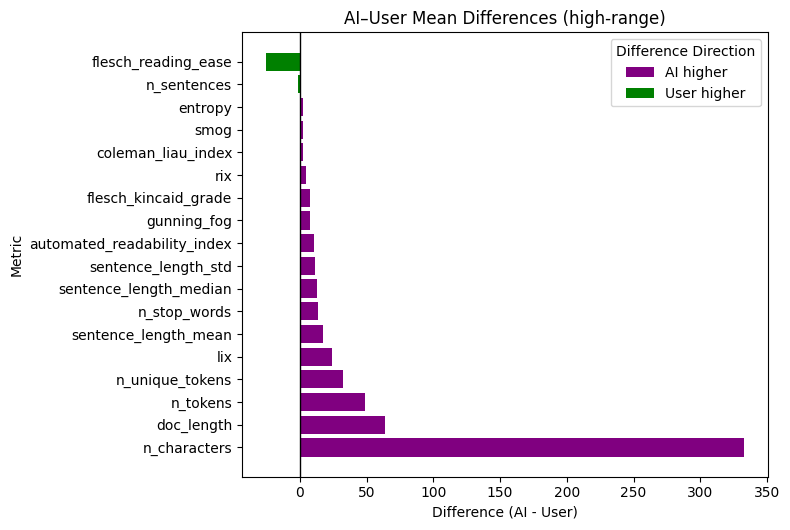

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Setup ---
df_numeric = df_full.select_dtypes('number')
metrics = [col for col in df_numeric.columns if not col.startswith('pos_') and col != 'perplexity' and col != 'per_word_perplexity']

# Compute mean per type
group_means = df_full.groupby('type')[metrics].mean().T
group_means['diff'] = group_means['ai'] - group_means['user']

# Compute ranges for grouping
min_vals = df_numeric.min()
max_vals = df_numeric.max()
ranges = max_vals - min_vals

# Define thresholds (tune if needed)
low_thr, mid_thr = 1, 10  # <1 small fractions, 1–10 mid, >10 high-range metrics

# Assign each metric to a scale group
scale_group = pd.cut(ranges, 
                     bins=[-np.inf, low_thr, mid_thr, np.inf], 
                     labels=['low-range', 'mid-range', 'high-range'])

group_means['scale_group'] = scale_group

# --- Plot each scale group separately ---
for group in ['low-range', 'mid-range', 'high-range']:
    subset = group_means[group_means['scale_group'] == group].sort_values('diff', ascending=False)
    if subset.empty:
        continue

    plt.figure(figsize=(8, max(4, len(subset)*0.3)))
    plt.barh(
        subset.index,
        subset['diff'],
        color=subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')
    )
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"AI–User Mean Differences ({group})")
    plt.xlabel("Difference (AI - User)")
    plt.ylabel("Metric")
        
    legend_elements = [
        Patch(facecolor='purple', label='AI higher'),
        Patch(facecolor='green', label='User higher')
    ]

    plt.legend(handles=legend_elements, title="Difference Direction")
    plt.tight_layout()
    plt.show()


### Interaction level analysis

In [54]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

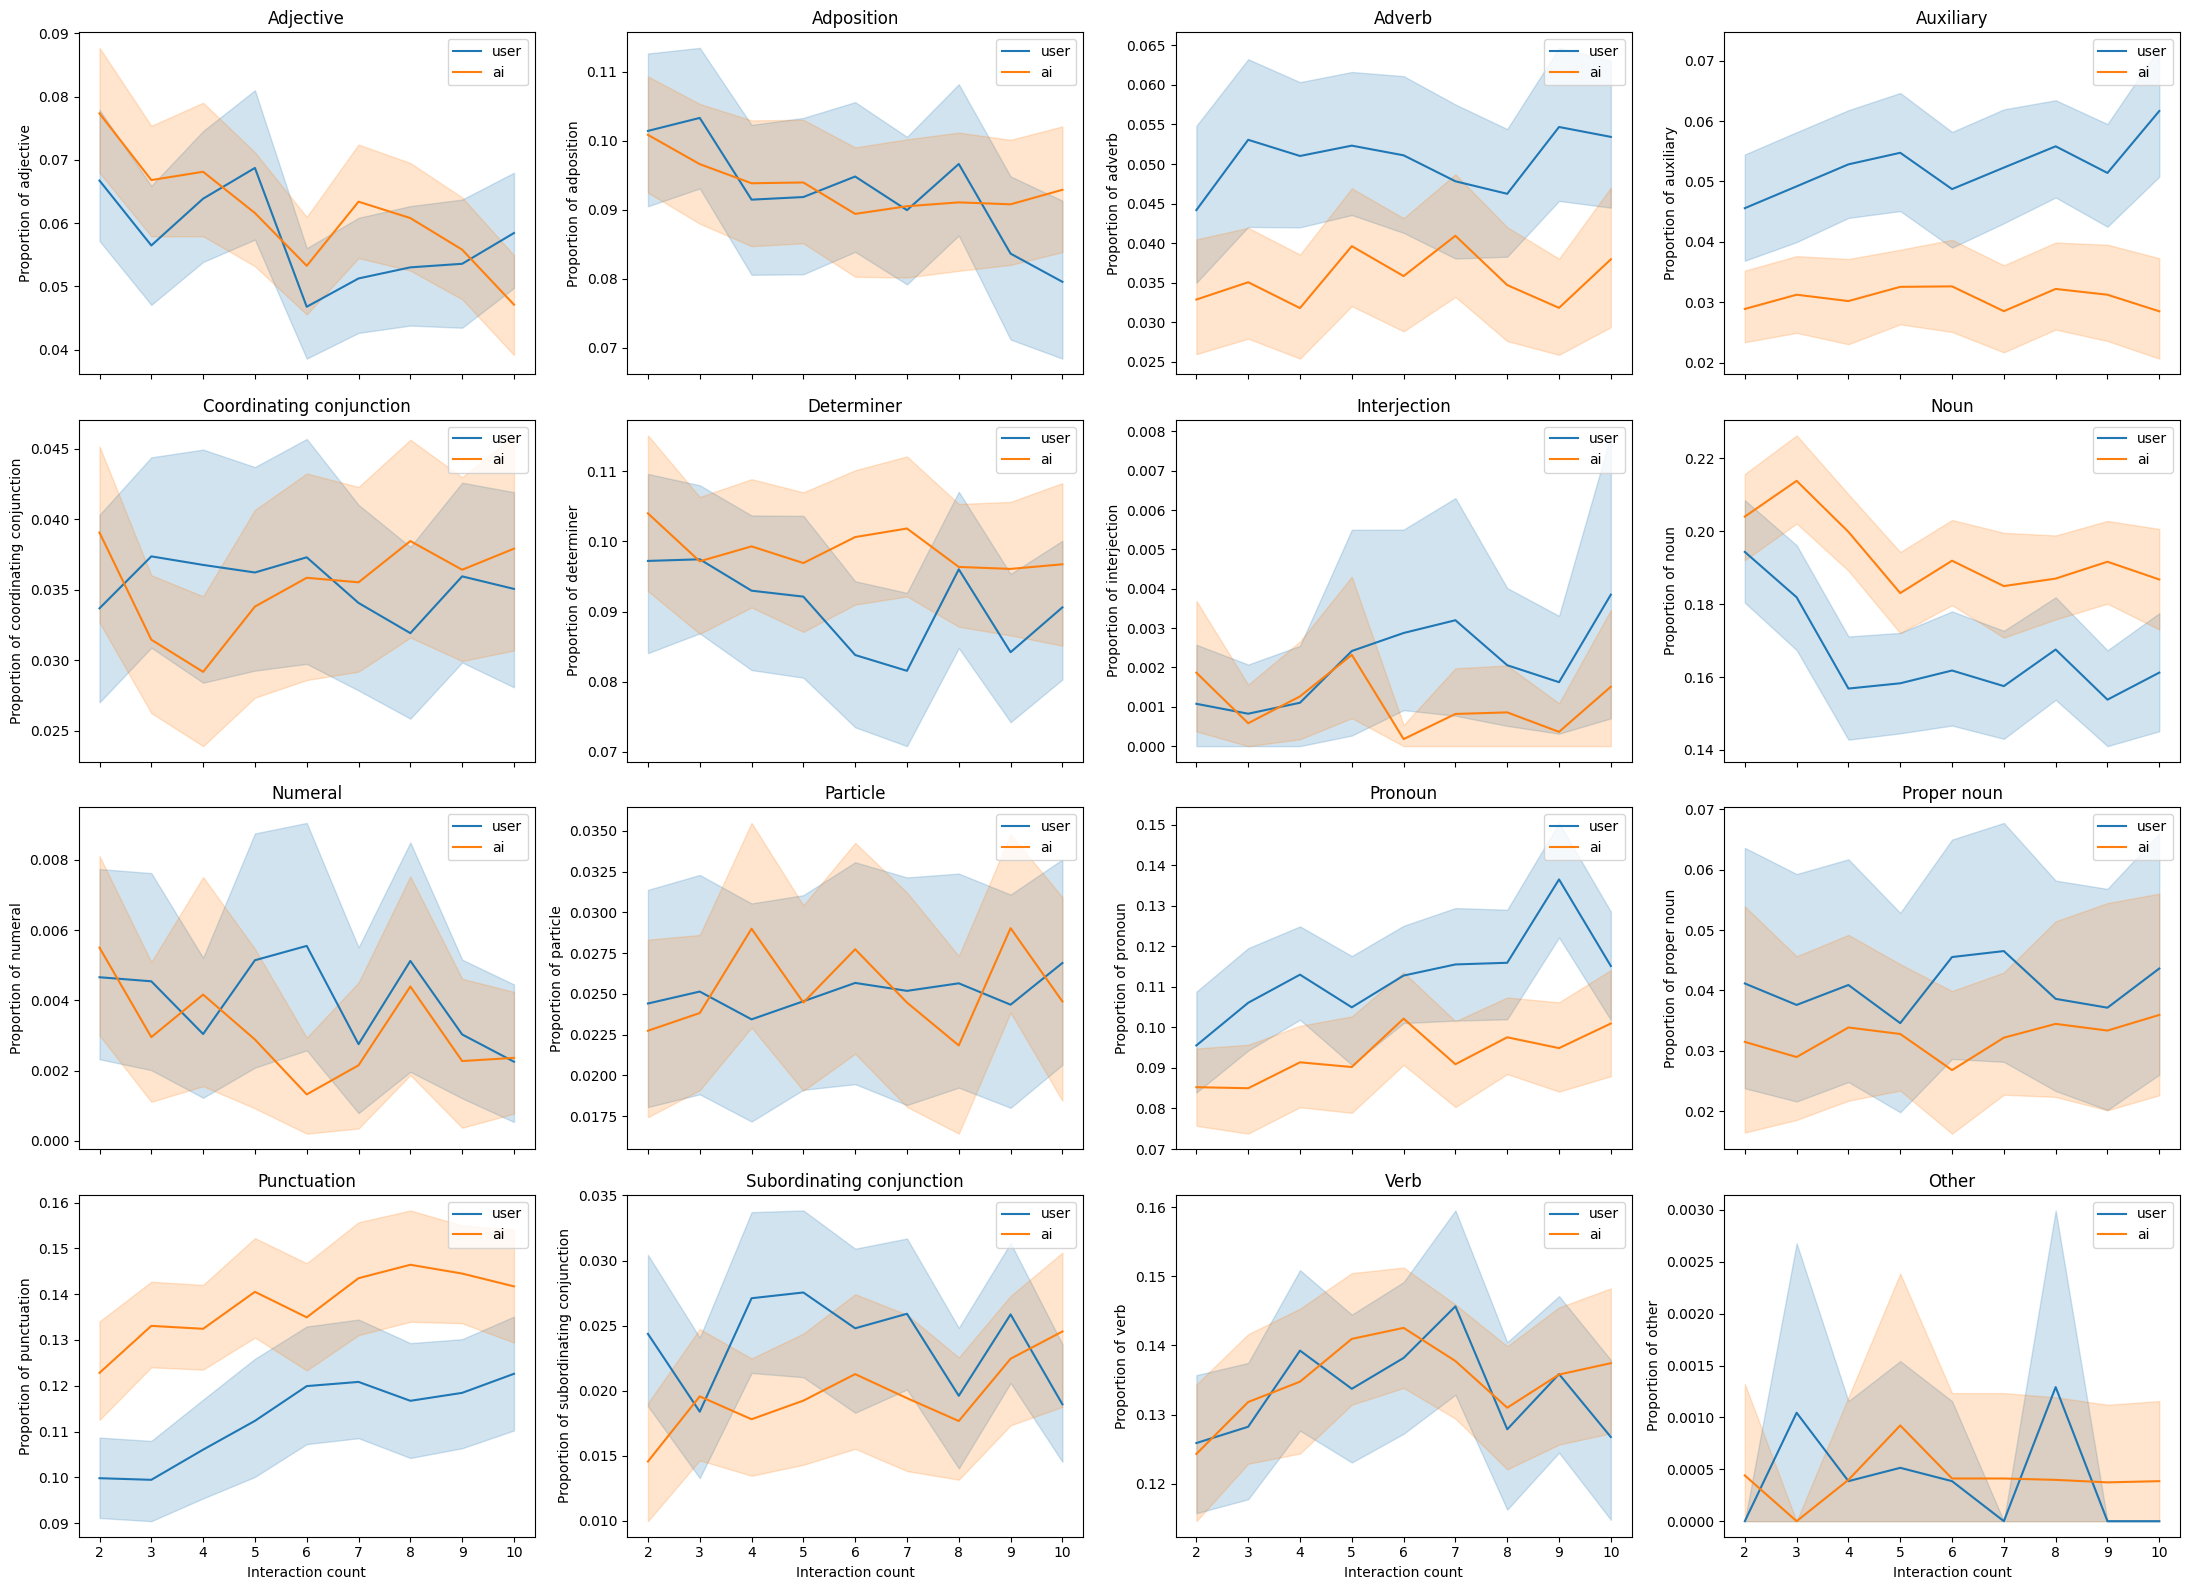

In [55]:
import warnings # To suppress some warnings
 
# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

df = df_inter.copy()
df = df[df['interaction_count'] > 1]

metrics = [col for col in df.columns if col.startswith('pos_') and col != 'pos_prop_SYM']

pos_names = {
    'ADJ': 'adjective',
    'ADP': 'adposition',
    'ADV': 'adverb',
    'AUX': 'auxiliary',
    'CCONJ': 'coordinating conjunction',
    'DET': 'determiner',
    'INTJ': 'interjection',
    'NOUN': 'noun',
    'NUM': 'numeral',
    'PART': 'particle',
    'PRON': 'pronoun',
    'PROPN': 'proper noun',
    'PUNCT': 'punctuation',
    'SCONJ': 'subordinating conjunction',
    'SYM': 'symbol',
    'VERB': 'verb',
    'X': 'other',
}

# sort metrics for consistent layout
metrics = sorted(metrics)

n = len(metrics)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, metrics):
    tag = m.replace("pos_prop_", "")
    p = pos_names.get(tag, tag)

    sns.lineplot(data=df, x=df["interaction_count"], y=m, hue="type", ax=ax)
    ax.set_title(p.capitalize())
    ax.set_ylabel(f"Proportion of {p}")
    ax.set_xlabel(f"Interaction count")
    ax.legend()

# remove unused axes if any
for ax in axes[len(metrics):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [56]:
import warnings # To suppress some warnings
 
def plot_interaction_descriptives(df = df_inter, metrics=None, starter=None): 
    # Suppress the specific FutureWarning
    warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
    if starter: 
        starter = starter
        df = df[df['starter'] == starter].copy()
        if starter == 'ai': 
            df = df[df['interaction_count'] > 1]
            
    
    ex_cols = df_inter.select_dtypes(exclude=["float", "int"]).columns.to_list()
    # df['type'] = df_inter['type']
    
    # sort metrics for consistent layout
    metrics = sorted([m for m in metrics if m not in ex_cols])

    n = len(metrics)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharex=True)
    axes = axes.flatten()
    fig.suptitle(f'{starter.upper()} starter', fontweight='semibold')

    for ax, m in zip(axes, metrics):

        sns.lineplot(data=df, x=df["interaction_count"], y=m, hue="type", ax=ax)
        ax.set_title(f"{" ".join([word.capitalize() for word in m.split('_')])} Across Interactions")
        ax.legend()

    # remove unused axes if any
    for ax in axes[len(metrics):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


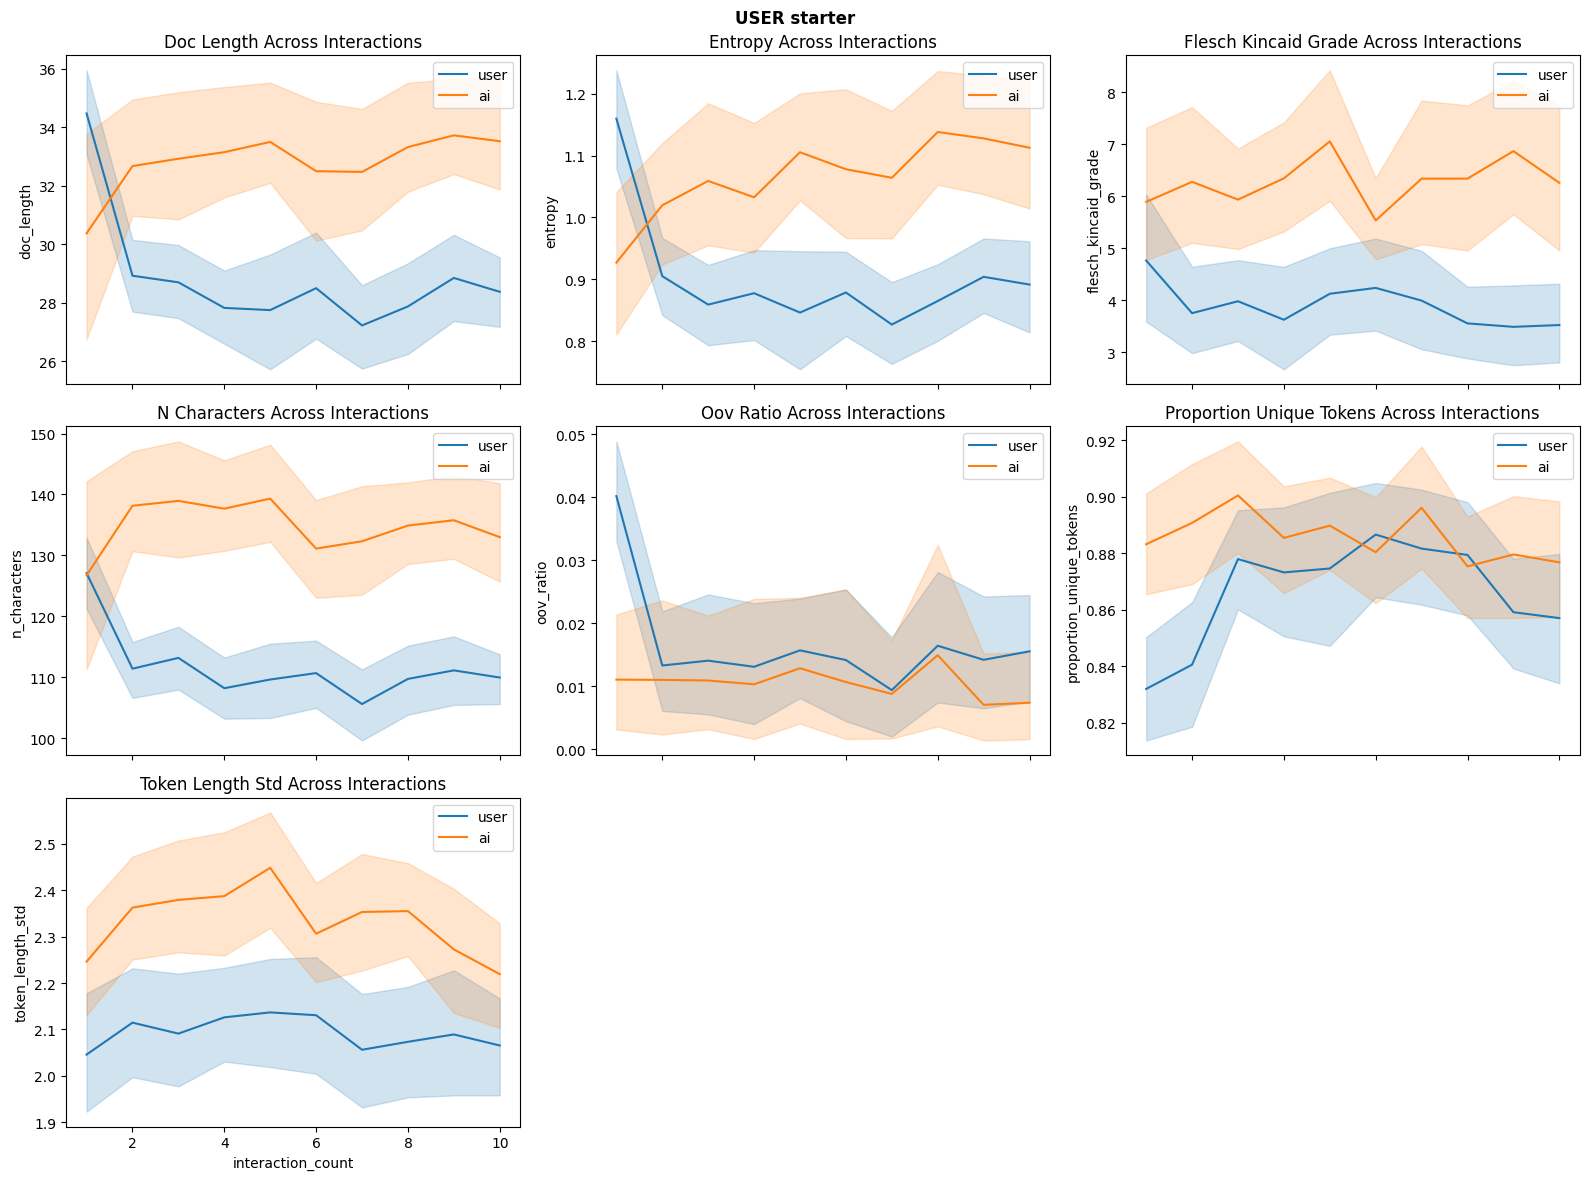

In [57]:
metrics = ['flesch_kincaid_grade', 'doc_length', 
'entropy', 
'n_characters', 
'oov_ratio', 
'proportion_unique_tokens', 
'token_length_std']

plot_interaction_descriptives(df=df_inter, metrics=metrics, starter='user')

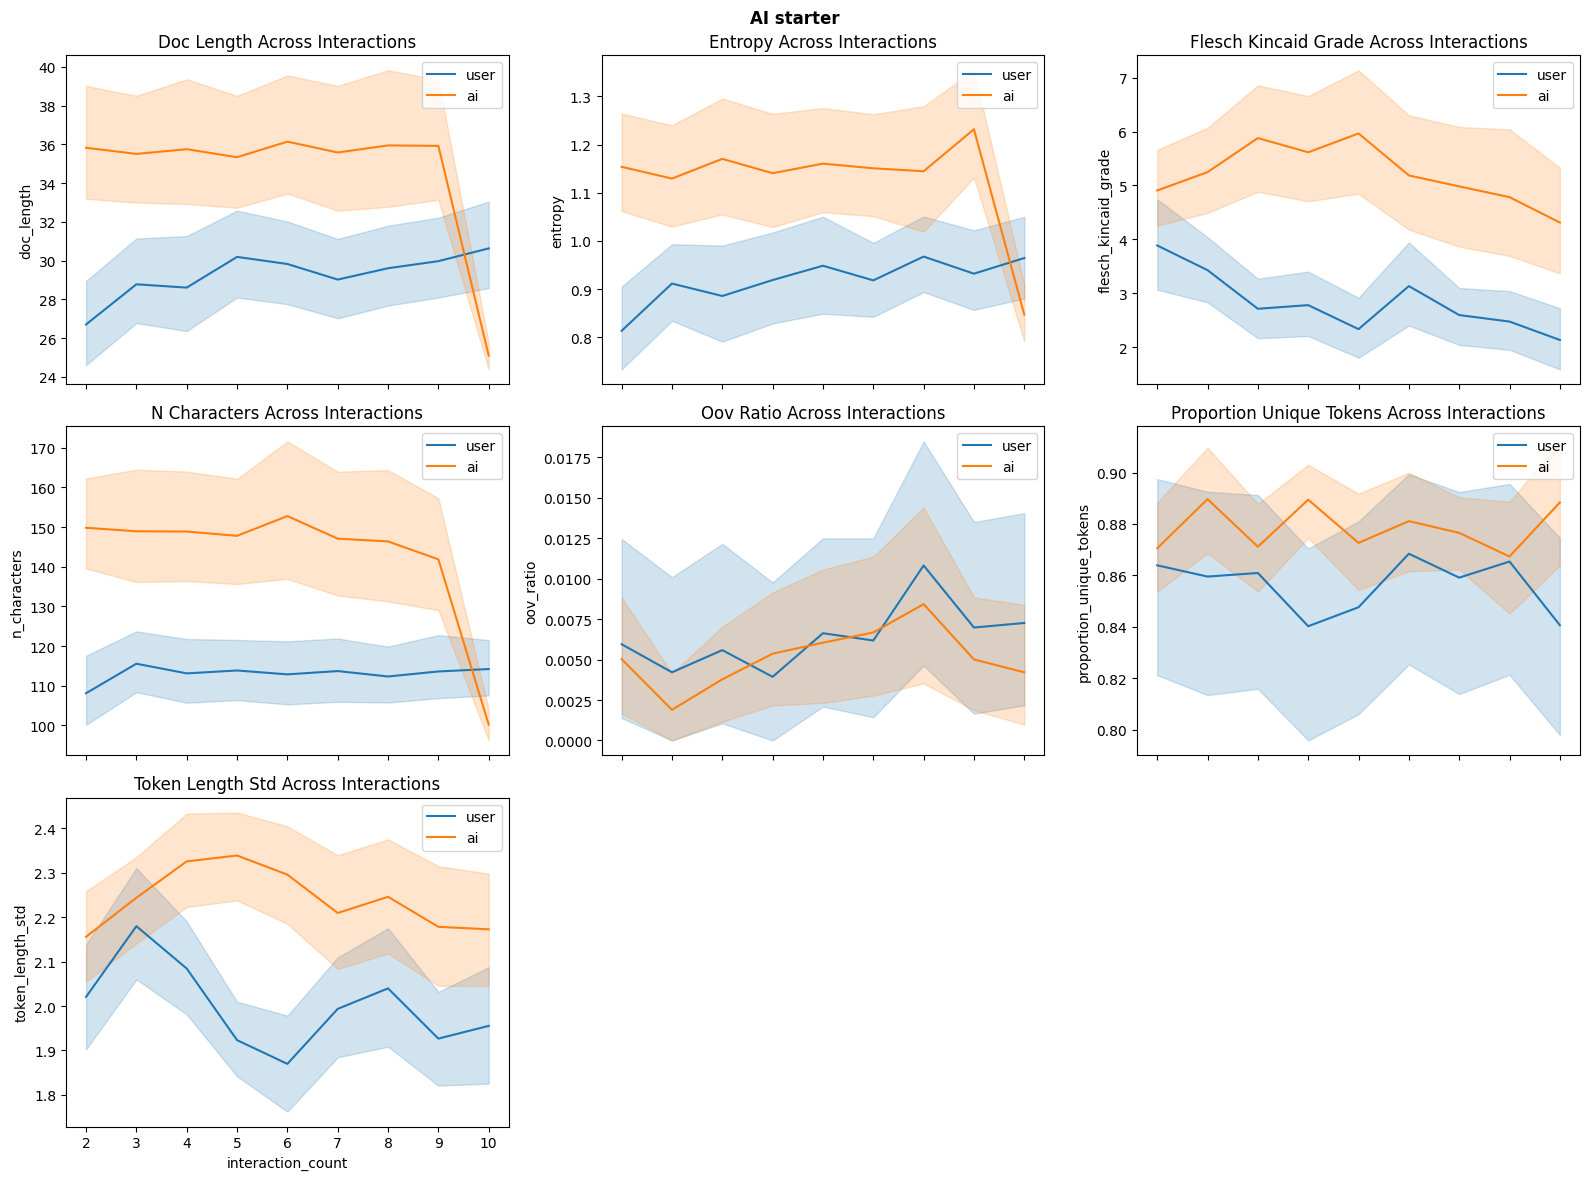

In [58]:
metrics = ['flesch_kincaid_grade', 'doc_length', 
'entropy', 
'n_characters', 
'oov_ratio', 
'proportion_unique_tokens', 
'token_length_std']

plot_interaction_descriptives(df=df_inter, metrics=metrics, starter='ai')